 Cybersecurity Threat Detection
 
**Dataset:** Network traffic logs with labeled attack types  
**Goal:** Detect malicious vs. benign traffic using basic ML models

## 1. Imports & Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100
print('✅ All libraries loaded.')

✅ All libraries loaded.


## 2. Load & Explore Data

In [13]:
df = pd.read_csv('cybersecurity_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 13)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [14]:
print('Missing values:')
print(df.isnull().sum())
print()
print('Label distribution:')
print(df['label'].value_counts())

Missing values:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

Label distribution:
label
0    9600
1     400
Name: count, dtype: int64


## 3. Data Visualization
Let's see how many benign vs malicious records we have, and what attack types exist.

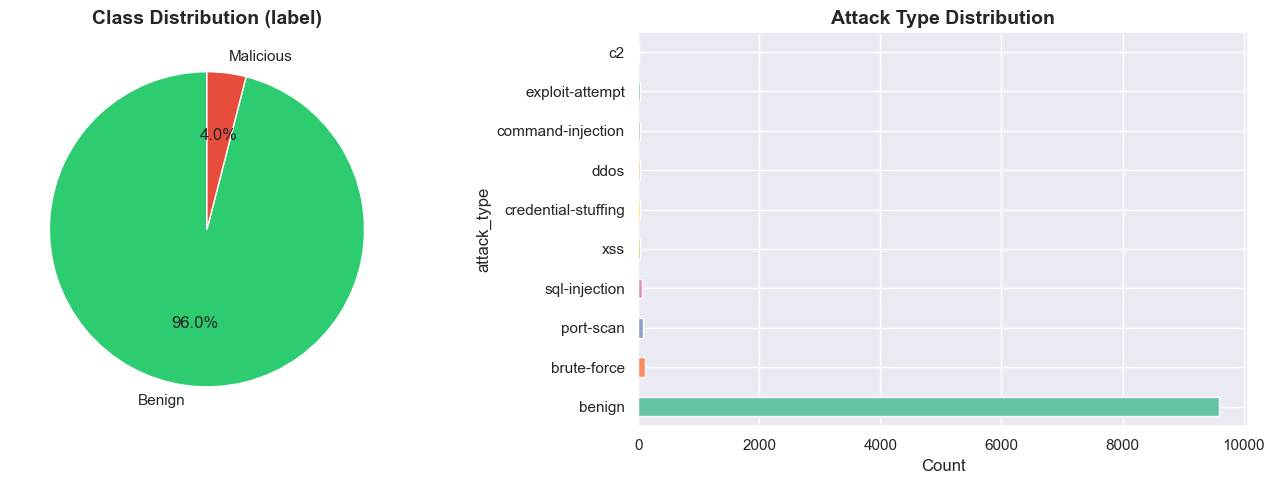

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_counts = df['label'].value_counts()
axes[0].pie(label_counts, labels=['Benign', 'Malicious'], autopct='%1.1f%%',colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Class Distribution (label)', fontsize=14, fontweight='bold')
attack_counts = df['attack_type'].value_counts()
attack_counts.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2', len(attack_counts)))
axes[1].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing
We clean the data and create a few simple new features to help the model.

In [16]:
df_proc = df.copy()
df_proc['timestamp'] = pd.to_datetime(df_proc['timestamp'])
df_proc['hour'] = df_proc['timestamp'].dt.hour
df_proc['is_night'] = ((df_proc['hour'] >= 22) | (df_proc['hour'] <= 5)).astype(int)
df_proc['byte_ratio'] = df_proc['bytes_sent'] / (df_proc['bytes_received'] +1)
df_proc['log_bytes_sent']     = np.log1p(df_proc['bytes_sent'])
df_proc['log_bytes_received'] = np.log1p(df_proc['bytes_received'])
df_proc['is_internal_traffic'] = df_proc['is_internal_traffic'].astype(int)
df_proc = pd.get_dummies(df_proc, columns=['protocol'], drop_first=True)
high_risk_ports = {22, 23, 445, 3389, 1433, 3306, 8080}
df_proc['dst_high_risk'] = df_proc['dst_port'].isin(high_risk_ports).astype(int)
df_proc['src_high_risk'] = df_proc['src_port'].isin(high_risk_ports).astype(int)
drop_cols = ['timestamp', 'src_ip', 'dst_ip', 'user_agent', 'url','attack_type', 'bytes_sent', 'bytes_received']
df_proc.drop(columns=drop_cols, inplace=True)
print('Processed shape:', df_proc.shape)
df_proc.head()

Processed shape: (10000, 13)


,src_port,dst_port,is_internal_traffic,label,hour,is_night,byte_ratio,log_bytes_sent,log_bytes_received,protocol_TCP,protocol_UDP,dst_high_risk,src_high_risk
0,56377,445,0,0,0,1,0.466667,8.990940,9.752955,True,False,1,0
1,51165,1433,0,0,0,1,0.255873,13.424494,14.787567,True,False,1,0
2,14948,1433,0,0,0,1,8.205486,12.665088,10.560282,True,False,1,0
3,36097,443,0,0,0,1,3.233634,11.169505,9.995884,True,False,0,0
4,445,21255,0,0,0,1,1.279779,9.451088,9.204322,True,False,0,1


## 5. Train-Test Split & Scaling
We split data into 80% training and 20% testing, then scale the features.

In [17]:
X = df_proc.drop(columns=['label'])
y = df_proc['label']
print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Train size: {X_train_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}')

Features: 12 | Samples: 10000
Train size: 8000 | Test size: 2000


## 6. Model Comparison
We compare 3 simple models using cross-validation.

In [18]:
models = {'Logistic Regression':LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),'Decision Tree':DecisionTreeClassifier(class_weight='balanced', random_state=42),'Random Forest':RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),}
results = []
for name, model in models.items():
    acc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    f1  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1').mean()
    roc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
    results.append({'Model': name, 'Accuracy': round(acc,3), 'F1 Score': round(f1,3), 'ROC-AUC': round(roc,3)})
    print(f'{name:25s} | Accuracy={acc:.3f}  F1={f1:.3f}  ROC-AUC={roc:.3f}')
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

Logistic Regression       | Accuracy=0.627  F1=0.124  ROC-AUC=0.685
Decision Tree             | Accuracy=0.946  F1=0.330  ROC-AUC=0.653
Random Forest             | Accuracy=0.962  F1=0.177  ROC-AUC=0.788


,Model,Accuracy,F1 Score,ROC-AUC
2,Random Forest,0.962,0.177,0.788
0,Logistic Regression,0.627,0.124,0.685
1,Decision Tree,0.946,0.330,0.653


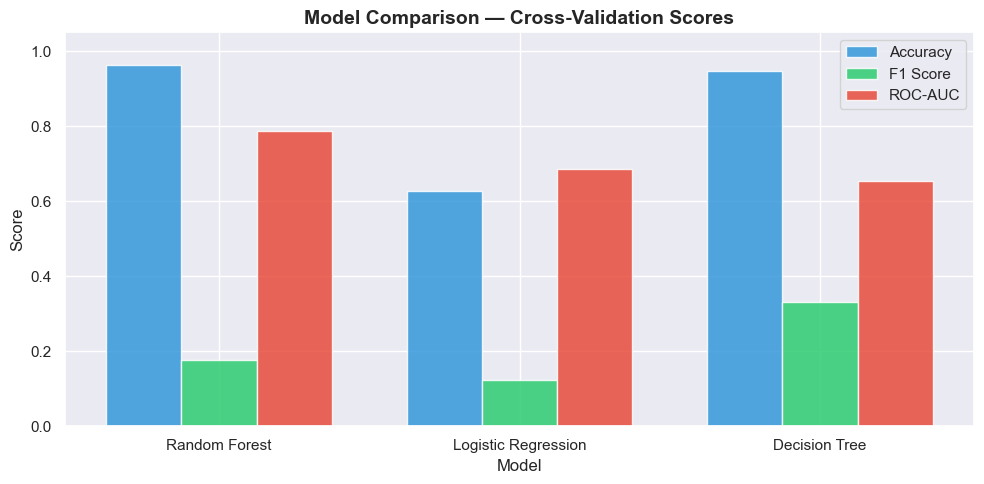

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Cross-Validation Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 7. Final Model — Logistic Regression
Logistic Regression is our chosen model. It predicts the probability that a record is malicious.

In [20]:
final_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
final_model.fit(X_train_scaled, y_train)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.62
y_pred = (y_proba >= threshold).astype(int)
print('=== Test Set Results ===')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred):.4f}')

=== Test Set Results ===
              precision    recall  f1-score   support

      Benign       0.97      0.82      0.89      1920
   Malicious       0.08      0.35      0.12        80

    accuracy                           0.80      2000
   macro avg       0.52      0.59      0.51      2000
weighted avg       0.93      0.80      0.86      2000

Accuracy : 0.8030
F1 Score : 0.1244


## 8. Confusion Matrix
Shows how many predictions were correct vs incorrect.

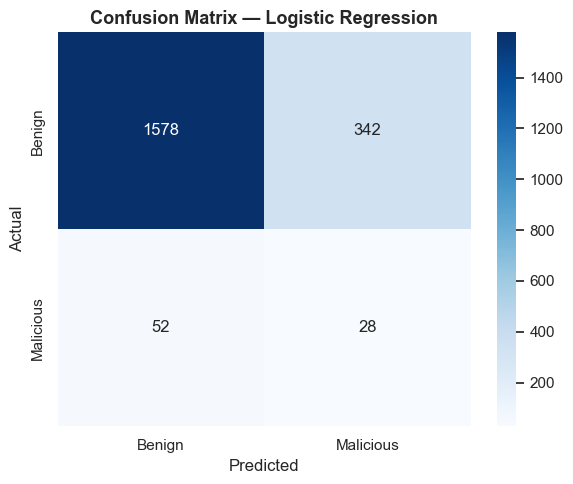

True Negatives  (Benign correctly identified):    1578
False Positives (Benign wrongly flagged):         342
False Negatives (Malicious missed):               52
True Positives  (Malicious correctly detected):   28


In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Benign', 'Malicious'],yticklabels=['Benign', 'Malicious'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Benign correctly identified):    {tn}')
print(f'False Positives (Benign wrongly flagged):         {fp}')
print(f'False Negatives (Malicious missed):               {fn}')
print(f'True Positives  (Malicious correctly detected):   {tp}')

## 9. Save Model

In [22]:
joblib.dump(final_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print('✅ Model saved successfully!')
print(f'   Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'   F1 Score : {f1_score(y_test, y_pred):.4f}')

✅ Model saved successfully!
   Accuracy : 0.8030
   F1 Score : 0.1244
